In [8]:
%matplotlib inline

import mne
from mne.datasets import eegbci
from mne.decoding import CSP
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneGroupOut

mne.set_log_level('WARNING')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'notebooks' in os.getcwd() else os.getcwd()
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

runs = [6, 10]
N_SUBJECTS = 109

print(f"Repo root: {REPO_ROOT}")

Repo root: C:\Various\Personal\Projects\neuro-decode


In [9]:
def load_subject(subject, runs=[6, 10], tmax=3.9):
    """Load, preprocess and epoch one subject. Returns X, y or None on failure."""
    try:
        raw_files = eegbci.load_data(subject, runs)
        raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True)
                                    for f in raw_files])
        mne.datasets.eegbci.standardize(raw)
        raw.set_montage(mne.channels.make_standard_montage('standard_1005'))

        if raw.info['sfreq'] != 160.0:
            raw.resample(160.0)
            print(f"  Subject {subject}: resampled from {raw.info['sfreq']} to 160 Hz")

        raw_filtered = raw.copy().filter(l_freq=8., h_freq=30.)

        events, _ = mne.events_from_annotations(raw_filtered)
        epochs = mne.Epochs(raw_filtered, events, event_id={'T1': 2, 'T2': 3},
                            tmin=0.0, tmax=tmax,
                            baseline=None, preload=True)

        X = epochs.get_data()
        y = epochs.events[:, 2]

        if len(np.unique(y)) < 2 or len(y) < 10:
            return None, None

        return X, y

    except Exception as e:
        print(f"Subject {subject} failed: {e}")
        return None, None

all_X, all_y, all_groups = [], [], []
failed = []

for subj in range(1, N_SUBJECTS + 1):
    X, y = load_subject(subj)
    if X is not None:
        all_X.append(X)
        all_y.append(y)
        all_groups.extend([subj] * len(y))
        if subj % 10 == 0:
            print(f"Loaded {subj}/{N_SUBJECTS} subjects...")
    else:
        failed.append(subj)

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
groups = np.array(all_groups)

print(f"\nDone!")
print(f"Total epochs: {len(y_all)} from {len(all_X)} subjects")
print(f"Failed subjects: {failed}")
print(f"X shape: {X_all.shape}")

data_dir = os.path.join(REPO_ROOT, 'data')
np.save(os.path.join(data_dir, 'X_all.npy'), X_all)
np.save(os.path.join(data_dir, 'y_all.npy'), y_all)
np.save(os.path.join(data_dir, 'groups.npy'), groups)

Loaded 10/109 subjects...
Loaded 20/109 subjects...
Loaded 30/109 subjects...
Loaded 40/109 subjects...
Loaded 50/109 subjects...
Loaded 60/109 subjects...
Loaded 70/109 subjects...
Loaded 80/109 subjects...
  Subject 88: resampled from 160.0 to 160 Hz
Loaded 90/109 subjects...
  Subject 92: resampled from 160.0 to 160 Hz


C:\Users\ameli\AppData\Local\Temp\ipykernel_61928\2019746948.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True)
C:\Users\ameli\AppData\Local\Temp\ipykernel_61928\2019746948.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True)


  Subject 100: resampled from 160.0 to 160 Hz
Loaded 100/109 subjects...

Done!
Total epochs: 3280 from 109 subjects
Failed subjects: []
X shape: (3280, 64, 625)


In [10]:
#CSP + LDA per subject
clf = Pipeline([
    ('csp', CSP(n_components=4, reg=None, log=True, norm_trace=False)),
    ('lda', LinearDiscriminantAnalysis())
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = {}
unique_subjects = np.unique(groups)

for subj in unique_subjects:
    mask = groups == subj
    X_subj = X_all[mask]
    y_subj = y_all[mask]
    scores = cross_val_score(clf, X_subj, y_subj, cv=cv, scoring='accuracy')
    accuracies[subj] = scores.mean()

accs = [accuracies[s] * 100 for s in unique_subjects]
print(f"Mean accuracy: {np.mean(accs):.1f}%")
print(f"Best subject: {unique_subjects[np.argmax(accs)]} ({max(accs):.1f}%)")
print(f"Worst subject: {unique_subjects[np.argmin(accs)]} ({min(accs):.1f}%)")
print(f"Above chance: {sum(a > 50 for a in accs)}/109 subjects")

Mean accuracy: 65.3%
Best subject: 7 (100.0%)
Worst subject: 101 (30.0%)
Above chance: 84/109 subjects


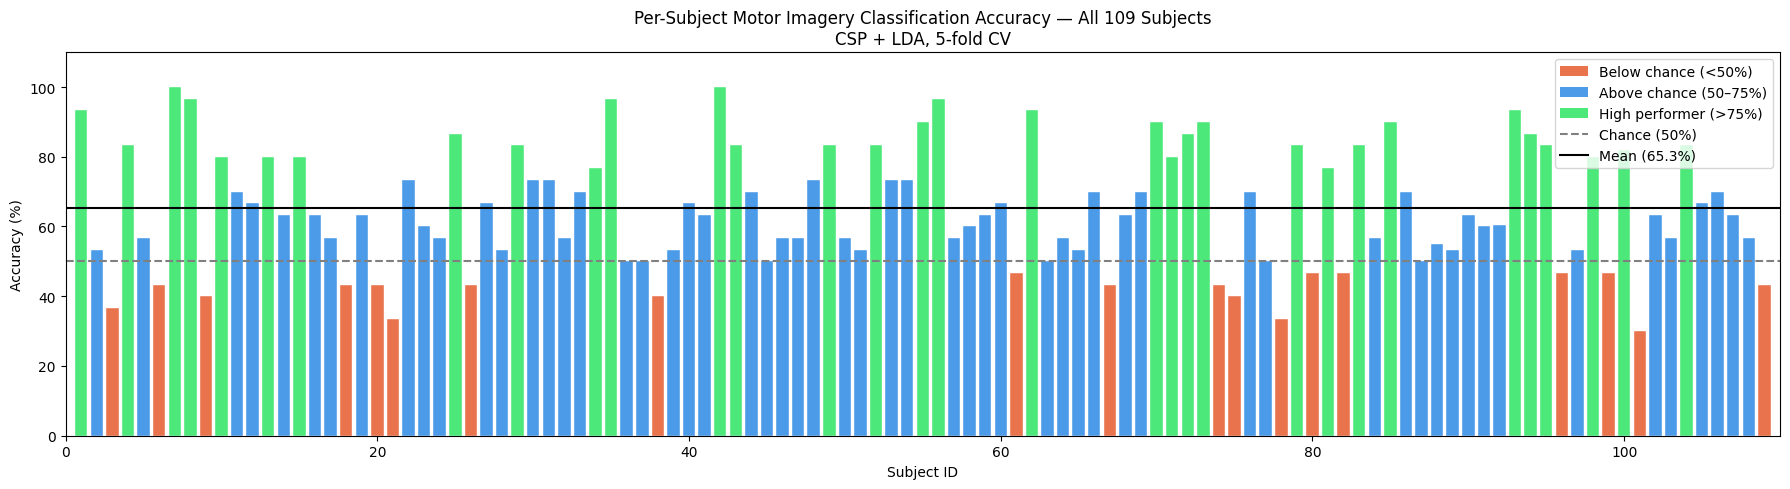

In [11]:
colors = ['#E8734C' if a < 50 else '#4C9BE8' if a < 75 else '#4CE87A' for a in accs]

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.bar(unique_subjects, accs, color=colors, edgecolor='white', linewidth=0.3)

ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.5, label='Chance (50%)')
ax.axhline(y=np.mean(accs), color='black', linestyle='-', linewidth=1.5,
           label=f'Mean ({np.mean(accs):.1f}%)')

ax.set_xlabel('Subject ID')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Subject Motor Imagery Classification Accuracy — All 109 Subjects\nCSP + LDA, 5-fold CV')
ax.set_xlim(0, 110)
ax.set_ylim(0, 110)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8734C', label='Below chance (<50%)'),
    Patch(facecolor='#4C9BE8', label='Above chance (50–75%)'),
    Patch(facecolor='#4CE87A', label='High performer (>75%)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label='Chance (50%)'),
    plt.Line2D([0], [0], color='black', label=f'Mean ({np.mean(accs):.1f}%)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '10_all_subjects_accuracy.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [13]:
#Leave-One-Subject-Out Cross-Validation
#Train on all subjects except one, test on the left-out subject
loso = LeaveOneGroupOut()

clf_loso = Pipeline([
    ('csp', CSP(n_components=4, reg=None, log=True, norm_trace=False)),
    ('lda', LinearDiscriminantAnalysis())
])

loso_scores = cross_val_score(clf_loso, X_all, y_all, 
                               groups=groups, cv=loso, 
                               scoring='accuracy')

print(f"LOSO Accuracy: {loso_scores.mean()*100:.1f}% ± {loso_scores.std()*100:.1f}%")
print(f"Per-subject 5-fold CV: {np.mean(accs):.1f}%")
print(f"\nDifference: {np.mean(accs) - loso_scores.mean()*100:.1f}% drop")
#print("This drop shows how much harder cross-subject generalization is.")

LOSO Accuracy: 59.6% ± 13.3%
Per-subject 5-fold CV: 65.3%

Difference: 5.7% drop


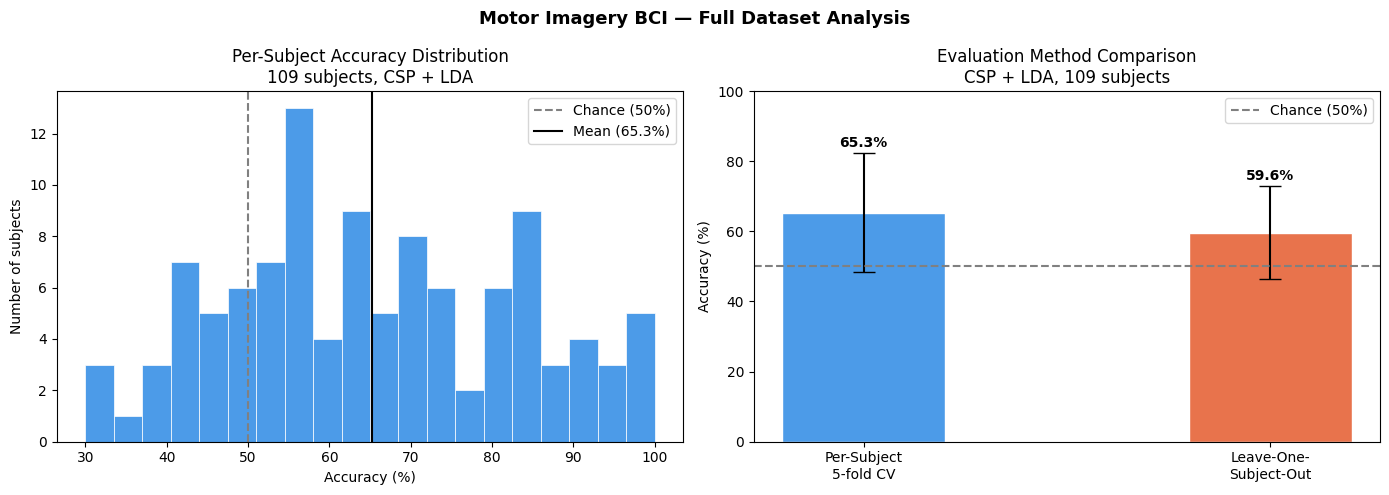

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Per-subject distribution
axes[0].hist(accs, bins=20, color='#4C9BE8', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='Chance (50%)')
axes[0].axvline(x=np.mean(accs), color='black', linewidth=1.5, 
                label=f'Mean ({np.mean(accs):.1f}%)')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_ylabel('Number of subjects')
axes[0].set_title('Per-Subject Accuracy Distribution\n109 subjects, CSP + LDA')
axes[0].legend()

# Right: Evaluation method comparison
methods = ['Per-Subject\n5-fold CV', 'Leave-One-\nSubject-Out']
means = [np.mean(accs), loso_scores.mean() * 100]
stds = [np.std(accs), loso_scores.std() * 100]

bars = axes[1].bar(methods, means, yerr=stds, capsize=8,
                   color=['#4C9BE8', '#E8734C'], edgecolor='white', width=0.4)
axes[1].axhline(y=50, color='gray', linestyle='--', linewidth=1.5, label='Chance (50%)')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Evaluation Method Comparison\nCSP + LDA, 109 subjects')
axes[1].legend()

for bar, mean, std in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 1,
                 f'{mean:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Motor Imagery BCI — Full Dataset Analysis', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '11_full_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()